In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from dataset.pairs.bin_reader import FacePairBinReader
from dataset.pairs.bin_visualizer import FacePairVisualizer
from utils.config_loader import Config
from utils.paths import ProjectPathResolver
from utils import analytics_tools as at

In [2]:
config_fpe = Config(path="config.fc_pair_eval.yaml")
path_resolver_fpe = ProjectPathResolver(config_fpe)

output_dir = path_resolver_fpe["paths.results_dir"]
os.makedirs(output_dir, exist_ok=True)
AGG_PLOTS_DIR = path_resolver_fpe["paths.all_aggregations_plot_dir"]
AGGREGATION_DIR = path_resolver_fpe["paths.all_aggregations_dir"]

In [3]:
reader = FacePairBinReader(path_resolver_fpe['paths.bin_subset'].path)
pairs = reader.load_pil_pairs()

In [4]:
df_committee_fcw112 = pd.read_csv(output_dir / "pair-gt_labat-cropped_image-warpe-112x112-len1180" / "committee_full_analysis.csv")
df_committee_ffidr = pd.read_csv(output_dir / "pair-gt_labat-full_image-default_480x640-len1180" / "committee_full_analysis.csv")

In [5]:
position = df_committee_fcw112.columns.get_loc('pair_id') + 1
df_committee_fcw112.insert(loc=position, column='pair_set', value="FCW112")
df_committee_ffidr.insert(loc=position, column='pair_set', value="FFIDR")
print(f"Length of FCW112 Full Committee {len(df_committee_fcw112)}")
print(f"Length of FFIDR Full Committee {len(df_committee_ffidr)}")

Length of FCW112 Full Committee 1180
Length of FFIDR Full Committee 1180


In [6]:
df_all_committee = pd.concat([df_committee_fcw112, df_committee_ffidr], ignore_index=True)
print(f"Length of All Full Committee Aggregation {len(df_all_committee)}")

Length of All Full Committee Aggregation 2360


In [7]:
df_all_committee

,pair_id,pair_set,ground_truth_fraude,pred_gemini,pred_chatgpt,pred_claude,justificativa_gemini,justificativa_chatgpt,justificativa_claude,similaridade_gemini,...,gemini_output_tokens,gemini_total_tokens,chatgpt_tempo_inferencia_s,chatgpt_input_tokens,chatgpt_output_tokens,chatgpt_total_tokens,claude_tempo_inferencia_s,claude_input_tokens,claude_output_tokens,claude_total_tokens
0,0,FCW112,False,False,False,False,"Os traços faciais, incluindo formato do nariz,...",Traços faciais e características semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,...,67,1236,3.1218,6219,33,6252,1.9203,360.0,62.0,422.0
1,1,FCW112,False,False,False,False,"Traços faciais como formato do nariz, olhos, b...",Traços faciais e estrutura semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,...,63,1239,1.4325,6219,33,6252,1.4935,360.0,63.0,423.0
2,2,FCW112,False,False,True,True,"Traços faciais como barba, bigode, formato do ...",Diferenças na iluminação e ângulo afetam a com...,Características faciais distintas. Formato do ...,0.92,...,64,1369,1.5288,6219,38,6257,1.6270,360.0,65.0,425.0
3,3,FCW112,False,False,False,False,"Traços faciais como formato do rosto, nariz, b...",Traços faciais e estrutura do rosto são muito ...,Traços faciais correspondentes: formato do ros...,0.92,...,62,1419,1.4655,6219,37,6256,1.4101,360.0,59.0,419.0
4,4,FCW112,False,False,True,False,"Traços faciais, formato do nariz, barba e bigo...",Diferenças notáveis na estrutura facial e no f...,Traços faciais correspondentes: formato do ros...,0.91,...,66,1485,1.3526,6219,40,6259,1.2600,360.0,61.0,421.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2355,1175,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros e caract...,Características faciais e gênero não correspondem,"Estrutura facial, formato do nariz e caracterí...",0.00,...,64,1086,1.8250,6219,34,6253,1.4516,1156.0,57.0,1213.0
2356,1176,FFIDR,True,True,True,False,As imagens mostram indivíduos de sexos e carac...,Imagens mostram pessoas diferentes em caracter...,"Traços faciais correspondentes: formato nariz,...",0.05,...,64,1223,1.0074,6219,35,6254,4.3486,1156.0,82.0,1238.0
2357,1177,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros e caract...,Características faciais e estrutura do rosto s...,"Sexo, estrutura facial e traços distintivos co...",0.00,...,65,1051,1.4110,6219,35,6254,1.3841,1156.0,55.0,1211.0
2358,1178,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros distinto...,Traços faciais e características físicas não c...,Qualidade insuficiente para análise biométrica...,0.00,...,62,1175,1.8710,6219,36,6255,1.6859,1156.0,81.0,1237.0


In [8]:
filter_committee_fcw112 = df_committee_fcw112[
    (df_committee_fcw112['unanimidade']) &
    (df_committee_fcw112['soma_votos_fraude'] == 3) &
    (df_committee_fcw112['ground_truth_fraude'] == False)
    ]
list_filtered_fcw112_pair_id = filter_committee_fcw112.index.tolist()

filter_committee_ffidr = df_committee_ffidr[
    (df_committee_ffidr['unanimidade']) &
    (df_committee_ffidr['soma_votos_fraude'] == 3) &
    (df_committee_ffidr['ground_truth_fraude'] == False)
    ]
list_filtered_ffidr_pair_id = filter_committee_ffidr.index.tolist()

print(f"Lista do FCW112 de Predições de fraudes quando não fraude. Quantidade: {len(list_filtered_fcw112_pair_id)}\nLista: {list_filtered_fcw112_pair_id}")
print(f"Lista do FFIDR de Predições de fraudes quando não fraude. Quantidade: {len(list_filtered_ffidr_pair_id)}\nLista: {list_filtered_ffidr_pair_id}")


Lista do FCW112 de Predições de fraudes quando não fraude. Quantidade: 74
Lista: [7, 9, 10, 11, 20, 23, 30, 32, 41, 61, 64, 286, 289, 294, 295, 315, 322, 326, 327, 329, 354, 358, 359, 367, 368, 371, 372, 380, 442, 457, 462, 466, 467, 476, 478, 479, 521, 536, 537, 541, 544, 548, 556, 558, 560, 566, 573, 575, 587, 598, 606, 607, 608, 609, 611, 622, 628, 633, 637, 638, 640, 641, 644, 711, 716, 719, 721, 765, 768, 770, 773, 774, 775, 776]
Lista do FFIDR de Predições de fraudes quando não fraude. Quantidade: 47
Lista: [7, 9, 21, 23, 32, 61, 62, 64, 327, 330, 352, 354, 359, 371, 372, 373, 442, 476, 477, 478, 487, 489, 521, 536, 548, 558, 560, 575, 595, 606, 609, 611, 620, 627, 628, 633, 644, 711, 716, 719, 721, 763, 765, 774, 775, 776, 779]


In [9]:
# Garantir que temos o dataframe agregado com os dois pair_sets
assert "pair_set" in df_all_committee.columns, "df_all_committee precisa ter a coluna 'pair_set'."

def acc_pr_rec_f1_auc(y_pred_bool, y_true, score_continuo=None):
    """Helper: retorna (acc, f1, auc) dado y_pred binário e score opcional."""
    y_pred = y_pred_bool.astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # AUC só faz sentido se tiver as duas classes presentes
    auc = None
    if score_continuo is not None:
        try:
            auc = roc_auc_score(y_true, score_continuo.astype(float))
        except ValueError:
            auc = None
    return acc, precision, recall, f1, auc

def compute_summary_for_df(df: pd.DataFrame, label: str) -> dict:
    """Calcula métricas de acurácia e concordância para um subconjunto do comitê."""
    total_pares = len(df)

    # LLMs (scores de fraude = 1 - similaridade)
    acc_gemini, pr_gemini, rec_gemini, f1_gemini, auc_gemini = acc_pr_rec_f1_auc(
        df['pred_gemini'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['similaridade_gemini']
    )
    acc_chatgpt, pr_chatgpt, rec_chatgpt, f1_chatgpt, auc_chatgpt = acc_pr_rec_f1_auc(
        df['pred_chatgpt'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['similaridade_chatgpt']
    )
    acc_claude, pr_claude, rec_claude, f1_claude, auc_claude = acc_pr_rec_f1_auc(
        df['pred_claude'], df['ground_truth_fraude'],
        score_continuo=1.0 - df['similaridade_claude']
    )

    # Comitê: score contínuo = proporção de votos de fraude (entre 0 e 1)
    n_modelos_votando = 6  # 3 LLMs + 3 baselines
    score_comite = df['soma_votos_fraude'] / n_modelos_votando

    acc_comite, pr_comite, rec_comite, f1_comite, auc_comite = acc_pr_rec_f1_auc(
        df['pred_maioria'], df['ground_truth_fraude'],
        score_continuo=score_comite
    )

    unanimidade = df['unanimidade'].astype(bool)
    divergencia = df['divergencia'].astype(bool)
    comite_acertou = df['comite_acertou'].astype(bool)

    unanimes = int(unanimidade.sum())
    divergentes = int(divergencia.sum())

    unanimous_correct = int((unanimidade & comite_acertou).sum())
    unanimous_wrong = int((unanimidade & ~comite_acertou).sum())
    divergent_correct = int((divergencia & comite_acertou).sum())
    divergent_wrong = int((divergencia & ~comite_acertou).sum())

    return {
        "pair_set": label,
        "n_pares": total_pares,
        "acc_gemini": acc_gemini,
        "acc_chatgpt": acc_chatgpt,
        "acc_claude": acc_claude,
        "acc_comite": acc_comite,

        # --- F1 ---
        "f1_gemini": f1_gemini,
        "f1_chatgpt": f1_chatgpt,
        "f1_claude": f1_claude,
        "f1_comite": f1_comite,

        # --- Precision ---
        "pr_gemini": pr_gemini,
        "pr_chatgpt": pr_chatgpt,
        "pr_claude": pr_claude,
        "pr_comite": pr_comite,

        # --- Recall ---
        "rec_gemini": rec_gemini,
        "rec_chatgpt": rec_chatgpt,
        "rec_claude": rec_claude,
        "rec_comite": rec_comite,

        # --- AUC (podem ser None se só tiver uma classe no subset) ---
        "auc_gemini": auc_gemini,
        "auc_chatgpt": auc_chatgpt,
        "auc_claude": auc_claude,
        "auc_comite": auc_comite,

        "pct_unanimidade": unanimes / total_pares if total_pares > 0 else np.nan,
        "pct_divergencia": divergentes / total_pares if total_pares > 0 else np.nan,
        "unanimous_count": unanimes,
        "divergent_count": divergentes,
        "unanimous_correct": unanimous_correct,
        "unanimous_wrong": unanimous_wrong,
        "divergent_correct": divergent_correct,
        "divergent_wrong": divergent_wrong,
        "alucinacao_coletiva": unanimous_wrong,
    }

# Lista de resumos: um por pair_set + um geral
resumos = []

for pair_set, df_sub in df_all_committee.groupby("pair_set"):
    resumos.append(compute_summary_for_df(df_sub, pair_set))

# Linha agregada (todos os pares)
resumos.append(compute_summary_for_df(df_all_committee, "ALL"))

summary_table = pd.DataFrame(resumos).set_index("pair_set")

# Se quiser ver porcentagens já formatadas como string para o notebook / artigo:
summary_table_fmt = summary_table.copy()
for col in ["acc_gemini", "acc_chatgpt", "acc_claude", "acc_comite", "pct_unanimidade", "pct_divergencia"]:
    summary_table_fmt[col] = (summary_table_fmt[col] * 100).map(lambda v: f"{v:.2f}%" if pd.notnull(v) else "NaN")

summary_table_fmt

,n_pares,acc_gemini,acc_chatgpt,acc_claude,acc_comite,f1_gemini,f1_chatgpt,f1_claude,f1_comite,pr_gemini,...,auc_comite,pct_unanimidade,pct_divergencia,unanimous_count,divergent_count,unanimous_correct,unanimous_wrong,divergent_correct,divergent_wrong,alucinacao_coletiva
pair_set,,,,,,,,,,,,,,,,,,,,,
FCW112,1180,82.12%,85.25%,69.49%,84.58%,0.853574,0.886719,0.750693,0.880263,0.817819,...,0.868266,65.00%,35.00%,767,413,692,75,306,107,75
FFIDR,1180,86.53%,91.10%,73.90%,88.05%,0.892349,0.928328,0.784615,0.905686,0.836294,...,0.919358,71.44%,28.56%,843,337,796,47,243,94,47
ALL,2360,84.32%,88.18%,71.69%,86.31%,0.873201,0.907031,0.767571,0.892869,0.827273,...,0.894517,68.22%,31.78%,1610,750,1488,122,549,201,122


In [ ]:
summary_json_path = AGGREGATION_DIR / "summary_flc_committee.json"

summary_table.to_json(summary_json_path, orient="index", indent=2)
print(f"Resumo salvo em JSON: {summary_json_path}")

In [11]:
cols_comite = [c for c in summary_table_fmt.columns if c.endswith("comite")]
summary_table_comite = summary_table[cols_comite]
summary_table_comite

,acc_comite,f1_comite,pr_comite,rec_comite,auc_comite
pair_set,,,,,
FCW112,0.845763,0.880263,0.805054,0.970972,0.868266
FFIDR,0.880508,0.905686,0.839950,0.982583,0.919358
ALL,0.863136,0.892869,0.822236,0.976778,0.894517


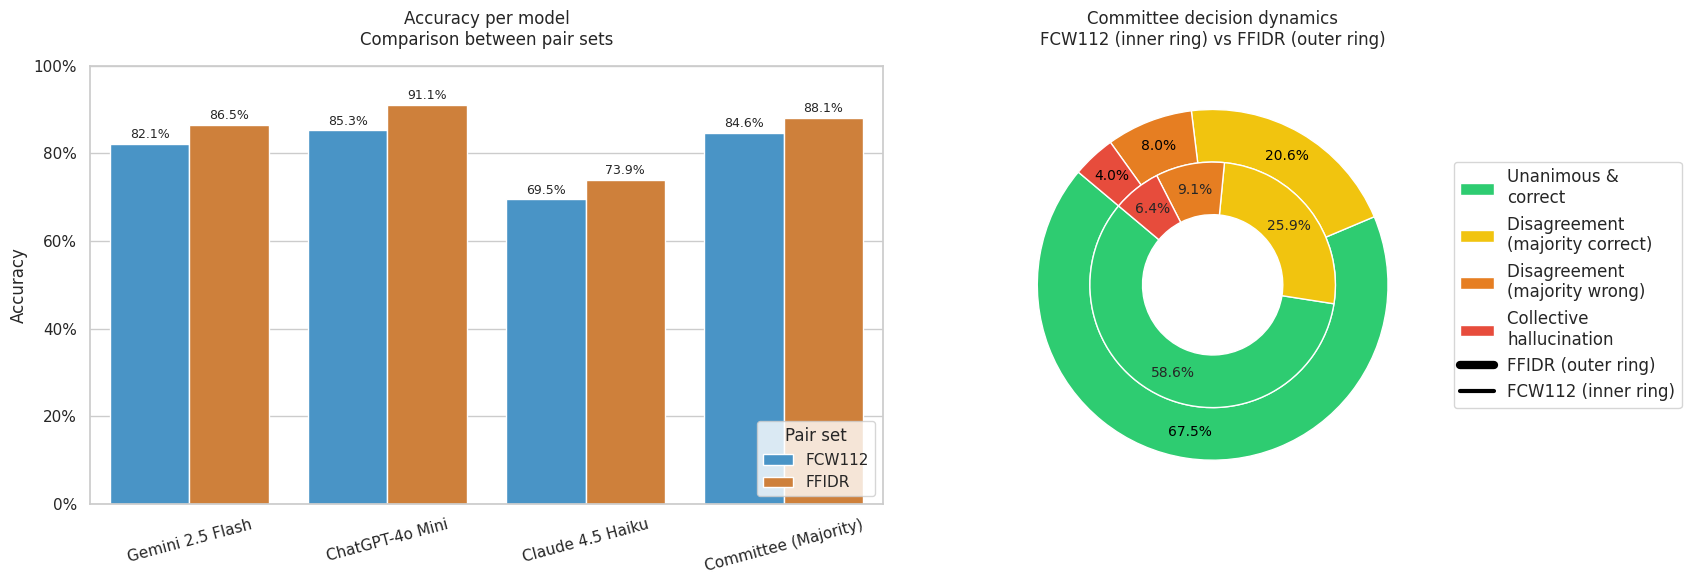

In [16]:
# --- GRÁFICOS PARA O ARTIGO (VERSÃO PARA PAPER) ---

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ============================================================
# 1) BAR CHART: ACCURACY PER MODEL (FCW112 vs FFIDR)
# ============================================================

# Extract accuracies by model for each pair set
acc_data = summary_table.loc[["FCW112", "FFIDR"], ["acc_gemini", "acc_chatgpt", "acc_claude", "acc_comite"]]
acc_data = acc_data.reset_index().rename(columns={"pair_set": "pair_set"})

# Long format for seaborn
acc_long = acc_data.melt(
    id_vars="pair_set",
    value_vars=["acc_gemini", "acc_chatgpt", "acc_claude", "acc_comite"],
    var_name="model",
    value_name="accuracy"
)

# Pretty labels for models
model_labels = {
    "acc_gemini": "Gemini 2.5 Flash",
    "acc_chatgpt": "ChatGPT-4o Mini",
    "acc_claude": "Claude 4.5 Haiku",
    "acc_comite": "Committee (Majority)",
}
acc_long["model"] = acc_long["model"].map(model_labels)

ax_bar = axes[0]
sns.barplot(
    data=acc_long,
    x="model",
    y="accuracy",
    hue="pair_set",
    palette=["#3498db", "#e67e22"],
    ax=ax_bar
)

ax_bar.set_title("Accuracy per model\nComparison between pair sets", fontsize=12, pad=15)
ax_bar.set_xlabel("")
ax_bar.set_ylabel("Accuracy")
ax_bar.set_ylim(0, 1.0)
ax_bar.tick_params(axis='x', rotation=15)

# Y-axis in percentage
ax_bar.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))

# Percentage labels on top of bars
for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt=lambda v: f"{v:.1%}", padding=2, fontsize=9)

ax_bar.legend(title="Pair set", loc="lower right")

# ============================================================
# 2) DOUBLE DONUT PIE CHART: COMMITTEE DECISION DYNAMICS
#    Inner ring = FCW112, Outer ring = FFIDR
# ============================================================

def compute_pizza_sizes(df):
    """Return the 4 counts for the committee decision dynamics pie chart."""
    unanimous_correct = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_correct = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_wrong = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == False)])
    unanimous_wrong = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == False)])
    return [unanimous_correct, divergent_majority_correct, divergent_majority_wrong, unanimous_wrong]

# sizes_fcw112 = compute_pizza_sizes(df_committee_fcw112)
# sizes_ffidr = compute_pizza_sizes(df_committee_ffidr)

sizes_fcw112 = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] == 'FCW112'])
sizes_ffidr = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] ==  'FFIDR'])

labels_en = [
    "Unanimous &\ncorrect",
    "Disagreement \n(majority correct)",
    "Disagreement \n(majority wrong)",
    "Collective \nhallucination",
]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

ax_pie = axes[1]

total_fcw112 = sum(sizes_fcw112)
total_ffidr = sum(sizes_ffidr)

def autopct_inside(pct):
    return f"{pct:.1f}%"

# Outer ring: FFIDR (percent text inside outer annulus)
wedges_outer, texts_outer, autotexts_outer = ax_pie.pie(
    sizes_ffidr,
    radius=1.0,
    labels=None,
    colors=colors,
    startangle=140,
    autopct=autopct_inside,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor="white"),
    textprops=dict(color="black", fontsize=10),
)

# Inner ring: FCW112 (we will place text manually inside each wedge)
wedges_inner, texts_inner = ax_pie.pie(
    sizes_fcw112,
    radius=0.7,
    labels=None,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Place, for each inner wedge, a "label\nXX.X%" text inside the colored region
for wedge, value in zip(wedges_inner, sizes_fcw112):
    ang = (wedge.theta2 + wedge.theta1) / 2.0
    ang_rad = np.deg2rad(ang)

    # middle radius of the inner ring (0.7 outer, width=0.3 → inner radius 0.4, middle ~0.55)
    r = 0.55

    x = r * np.cos(ang_rad)
    y = r * np.sin(ang_rad)

    pct = 100.0 * value / total_fcw112 if total_fcw112 > 0 else 0.0

    ax_pie.text(
        x,
        y,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
    )

ax_pie.set(aspect="equal")
ax_pie.set_title("Committee decision dynamics\nFCW112 (inner ring) vs FFIDR (outer ring)", fontsize=12, pad=15,)

# Legend: colors → categories, lines → which ring is which dataset
handles_cat = [Patch(facecolor=c, edgecolor="white", label=lab) for c, lab in zip(colors, labels_en)]
handles_ring = [
    Line2D([0], [0], color="black", lw=6, label="FFIDR (outer ring)"),
    Line2D([0], [0], color="black", lw=3, label="FCW112 (inner ring)"),
]

ax_pie.legend(
    handles_cat + handles_ring,
    [h.get_label() for h in handles_cat + handles_ring],
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.0,
    fontsize=12,
)

at.save_plot(fig, AGG_PLOTS_DIR, "flc_committee_accuracy_and_concordance.png")

plt.tight_layout()
plt.show()

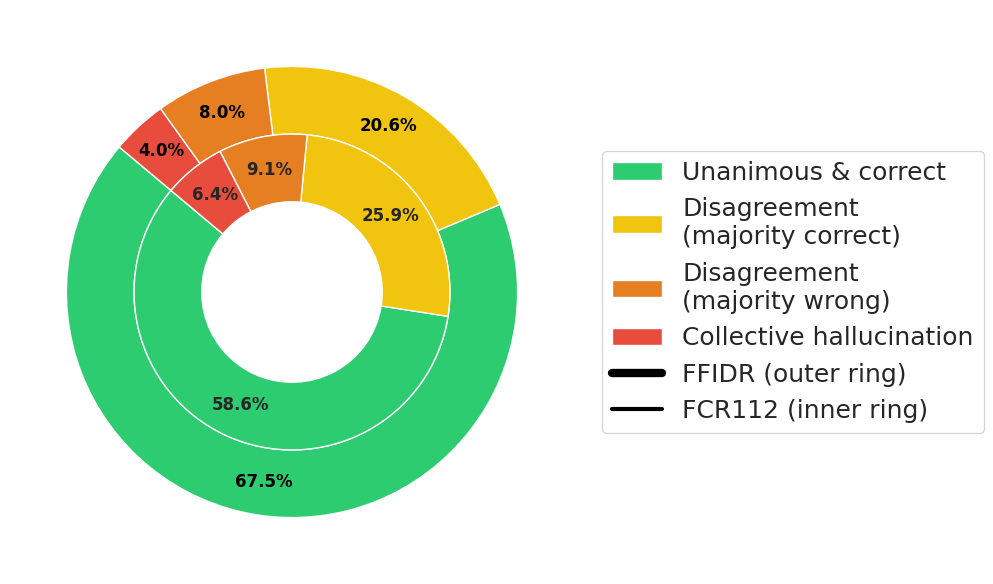

In [15]:
# ============================================================
# 2) DOUBLE DONUT PIE CHART: COMMITTEE DECISION DYNAMICS
#    Inner ring = FCW112, Outer ring = FFIDR
# ============================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(18, 6))

def compute_pizza_sizes(df):
    """Return the 4 counts for the committee decision dynamics pie chart."""
    unanimous_correct = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_correct = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == True)])
    divergent_majority_wrong = len(df[(df["divergencia"] == True) & (df["comite_acertou"] == False)])
    unanimous_wrong = len(df[(df["unanimidade"] == True) & (df["comite_acertou"] == False)])
    return [unanimous_correct, divergent_majority_correct, divergent_majority_wrong, unanimous_wrong]

# sizes_fcw112 = compute_pizza_sizes(df_committee_fcw112)
# sizes_ffidr = compute_pizza_sizes(df_committee_ffidr)

sizes_fcw112 = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] == 'FCW112'])
sizes_ffidr = compute_pizza_sizes(df_all_committee[df_all_committee['pair_set'] ==  'FFIDR'])

labels_en = [
    "Unanimous & correct",
    "Disagreement\n(majority correct)",
    "Disagreement\n(majority wrong)",
    "Collective hallucination",
]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

ax_pie = axes

total_fcw112 = sum(sizes_fcw112)
total_ffidr = sum(sizes_ffidr)

def autopct_inside(pct):
    return f"{pct:.1f}%"

# Outer ring: FFIDR (percent text inside outer annulus)
wedges_outer, texts_outer, autotexts_outer = ax_pie.pie(
    sizes_ffidr,
    radius=1.0,
    labels=None,
    colors=colors,
    startangle=140,
    autopct=autopct_inside,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor="white"),
    textprops=dict(color="black", fontsize=12, fontweight="bold"),
)

# Inner ring: FCW112 (we will place text manually inside each wedge)
wedges_inner, texts_inner = ax_pie.pie(
    sizes_fcw112,
    radius=0.7,
    labels=None,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Place, for each inner wedge, a "label\nXX.X%" text inside the colored region
for wedge, value in zip(wedges_inner, sizes_fcw112):
    ang = (wedge.theta2 + wedge.theta1) / 2.0
    ang_rad = np.deg2rad(ang)

    # middle radius of the inner ring (0.7 outer, width=0.3 → inner radius 0.4, middle ~0.55)
    r = 0.55

    x = r * np.cos(ang_rad)
    y = r * np.sin(ang_rad)

    pct = 100.0 * value / total_fcw112 if total_fcw112 > 0 else 0.0

    ax_pie.text(
        x,
        y,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

ax_pie.set(aspect="equal")
# ax_pie.set_title(
#     "Committee decision dynamics\nFCW112 (inner ring) vs FFIDR (outer ring)",
#     fontsize=12,
#     pad=15,
# )

# Legend: colors → categories, lines → which ring is which dataset
handles_cat = [Patch(facecolor=c, edgecolor="white", label=lab) for c, lab in zip(colors, labels_en)]
handles_ring = [
    Line2D([0], [0], color="black", lw=6, label="FFIDR (outer ring)"),
    Line2D([0], [0], color="black", lw=3, label="FCR112 (inner ring)"),
]

ax_pie.legend(
    handles_cat + handles_ring,
    [h.get_label() for h in handles_cat + handles_ring],
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.0,
    fontsize=18,
)

at.save_plot(fig, AGG_PLOTS_DIR, "flc_committee_double_donut_labeled.png")

plt.tight_layout()
plt.show()